# COMP VISION PROJECT
This jupyter notebook contains the training data for task 3 using the balanced dataset containing (cat + objects, objects only images)

## Task 1-2: Dataset Setup

In [1]:
# 1) Build 'coco_filtered_with_negatives_balanced/' with extracted data
#!python balance_yolo_dataset.py --source curated_yolo_with_negatives --output curated_yolo_with_negatives_balanced --seed 42 --copy-other-splits

# 2) Build curated_yolo_with_negatives_balanced/ with reproducible 80/10/10 split
#!python scripts/prepare_coco_subset.py --verify

## Common libraries + helper functions

In [1]:
%matplotlib inline
import gc
import math
from pathlib import Path

import cv2
import torch
from matplotlib import pyplot as plt
from ultralytics import YOLO

### HELPER FUNCTIONS
def display_image_subplots(image_filenames, image_dir, num_images, num_cols):
    """Display up to num_images in a subplot grid from image_dir."""
    if num_cols <= 0:
        raise ValueError("num_cols must be greater than 0")
    if num_images <= 0:
        raise ValueError("num_images must be greater than 0")
    if not image_filenames:
        raise ValueError("image_filenames cannot be empty")

    image_dir = Path(image_dir)
    selected_files = list(image_filenames[: min(num_images, len(image_filenames))])
    num_rows = math.ceil(len(selected_files) / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(15 * num_cols, 10 * num_rows))
    axes_list = axes.ravel().tolist() if hasattr(axes, "ravel") else [axes]

    for i, filename in enumerate(selected_files):
        img_path = image_dir / filename
        img = cv2.imread(str(img_path))

        if img is None:
            axes_list[i].text(0.5, 0.5, f"Missing:\n{filename}", ha="center", va="center")
            axes_list[i].set_title(filename)
            axes_list[i].axis("off")
            continue

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axes_list[i].imshow(img_rgb)
        axes_list[i].set_title(filename)
        axes_list[i].axis("off")

    for j in range(len(selected_files), len(axes_list)):
        axes_list[j].axis("off")

    plt.tight_layout()
    plt.show()


def clean_up(model=None):
    """Release model refs and clear CPU/GPU cached memory."""
    if model is not None:
        del model

    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

### CONSTANTS
GRAPH_FILENAMES = [
    "results.png",
    "confusion_matrix.png",
    "BoxF1_curve.png",
    "BoxR_curve.png",
    "BoxP_curve.png",
]

## Task 3

### Train: default settings

In [4]:

DATASET_DIR = "curated_yolo_with_negatives_balanced"

# 1) load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# 2) train using your dataset yaml
model.train(
    data=DATASET_DIR+"/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    seed=42,
    device=0  # use "cpu" if no GPU
)

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.32  Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=curated_yolo_with_negatives_balanced/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, 

c:\Users\Sonia Lim\anaconda3\envs\polyu_y3t2\Lib\site-packages\ultralytics\utils\plotting.py:872: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  from scipy.ndimage import gaussian_filter1d


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x0000020A4DF1CA40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

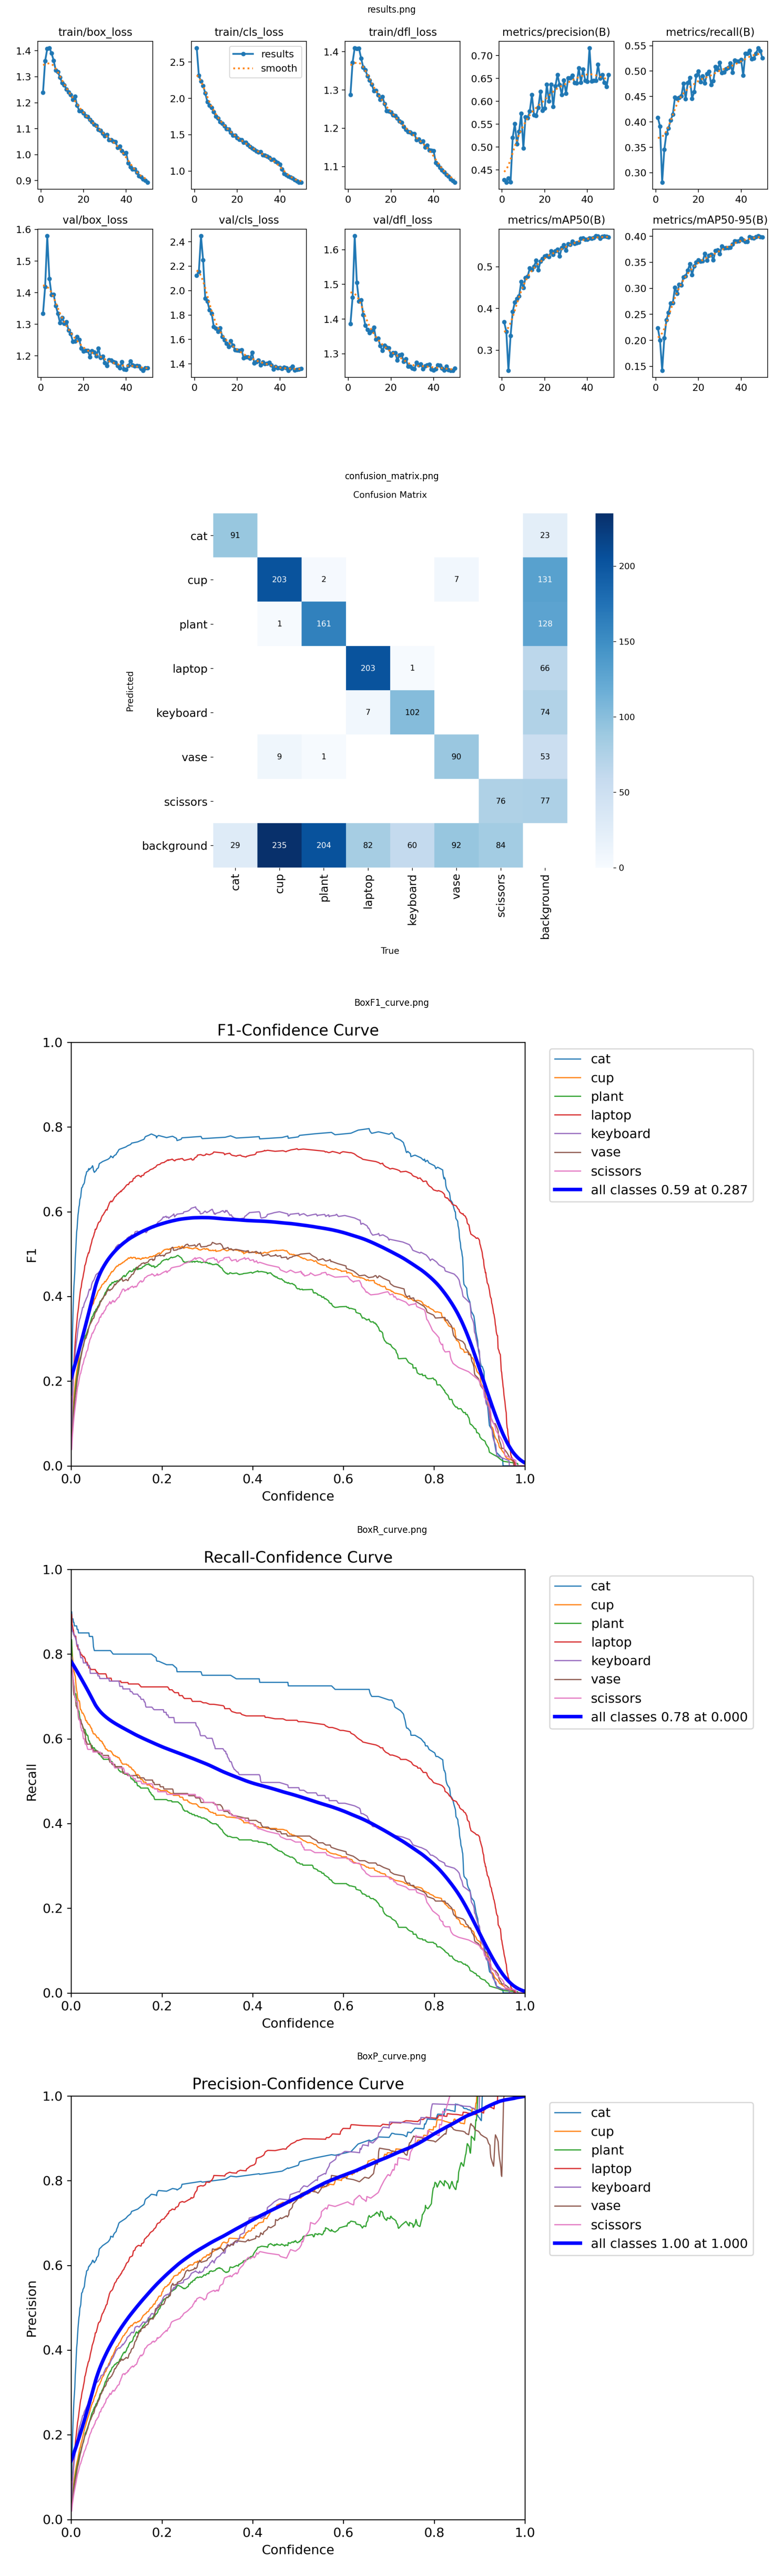

In [5]:
# 3) display training graphs
display_image_subplots(
    image_filenames=GRAPH_FILENAMES,
    image_dir="runs/detect/train",
    num_images=5,
    num_cols=1,
)

clean_up(model)

### Train 2: increase epochs from 50 - 100

In [ ]:
DATASET_DIR = "curated_yolo_with_negatives_balanced"

# 1) load pretrained YOLOv8 model
model = YOLO("yolov8n.pt")

# 2) train using your dataset yaml
model.train(
    data=DATASET_DIR+"/data.yaml",
    epochs=100,
    imgsz=640,
    batch=16,
    seed=42,
    device=0  # use "cpu" if no GPU
)

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.32  Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=curated_yolo_with_negatives_balanced/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0,

c:\Users\Sonia Lim\anaconda3\envs\polyu_y3t2\Lib\site-packages\ultralytics\utils\plotting.py:872: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  from scipy.ndimage import gaussian_filter1d


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002451A184D40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

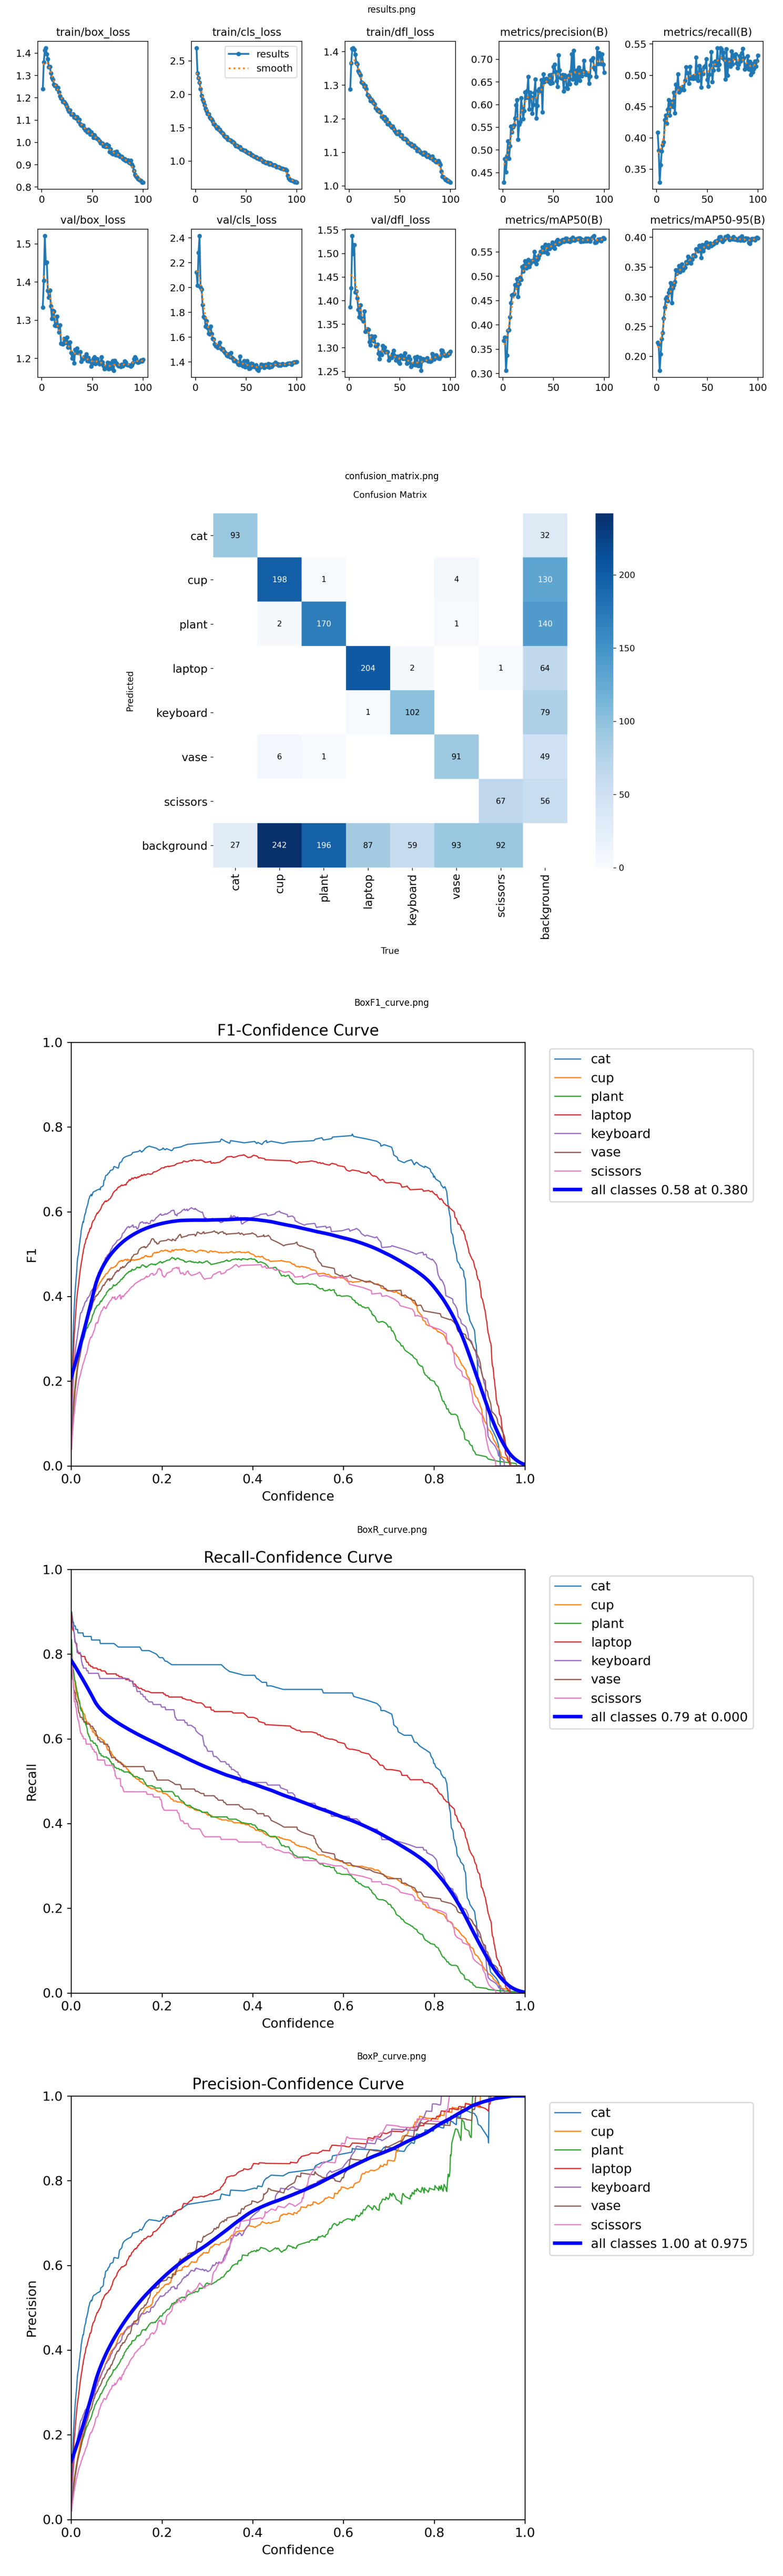

In [ ]:

display_image_subplots(
    image_filenames=GRAPH_FILENAMES,
    image_dir="runs/detect/train4",
    num_images=5,
    num_cols=1,
)
clean_up(model)

### Train 3: Change to larger Model (n -> s)
Note: reduced epochs to 50 and batch to 8 due to gpu capacity

In [2]:
DATASET_DIR = "curated_yolo_with_negatives_balanced"

# 1) load pretrained YOLOv8 model
model = YOLO("yolov8s.pt")

# 2) train using your dataset yaml
model.train(
    data=DATASET_DIR+"/data.yaml",
    epochs=50,
    imgsz=640,
    batch=8,
    seed=42,
    device=0,  # use "cpu" if no GPU
    workers=0,  # Fix for Windows multiprocessing issues
    patience=5
)

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.32  Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=curated_yolo_with_negatives_balanced/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, m

c:\Users\Sonia Lim\anaconda3\envs\polyu_y3t2\Lib\site-packages\ultralytics\utils\plotting.py:872: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.1)
  from scipy.ndimage import gaussian_filter1d


ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002A4B8AF4A40>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

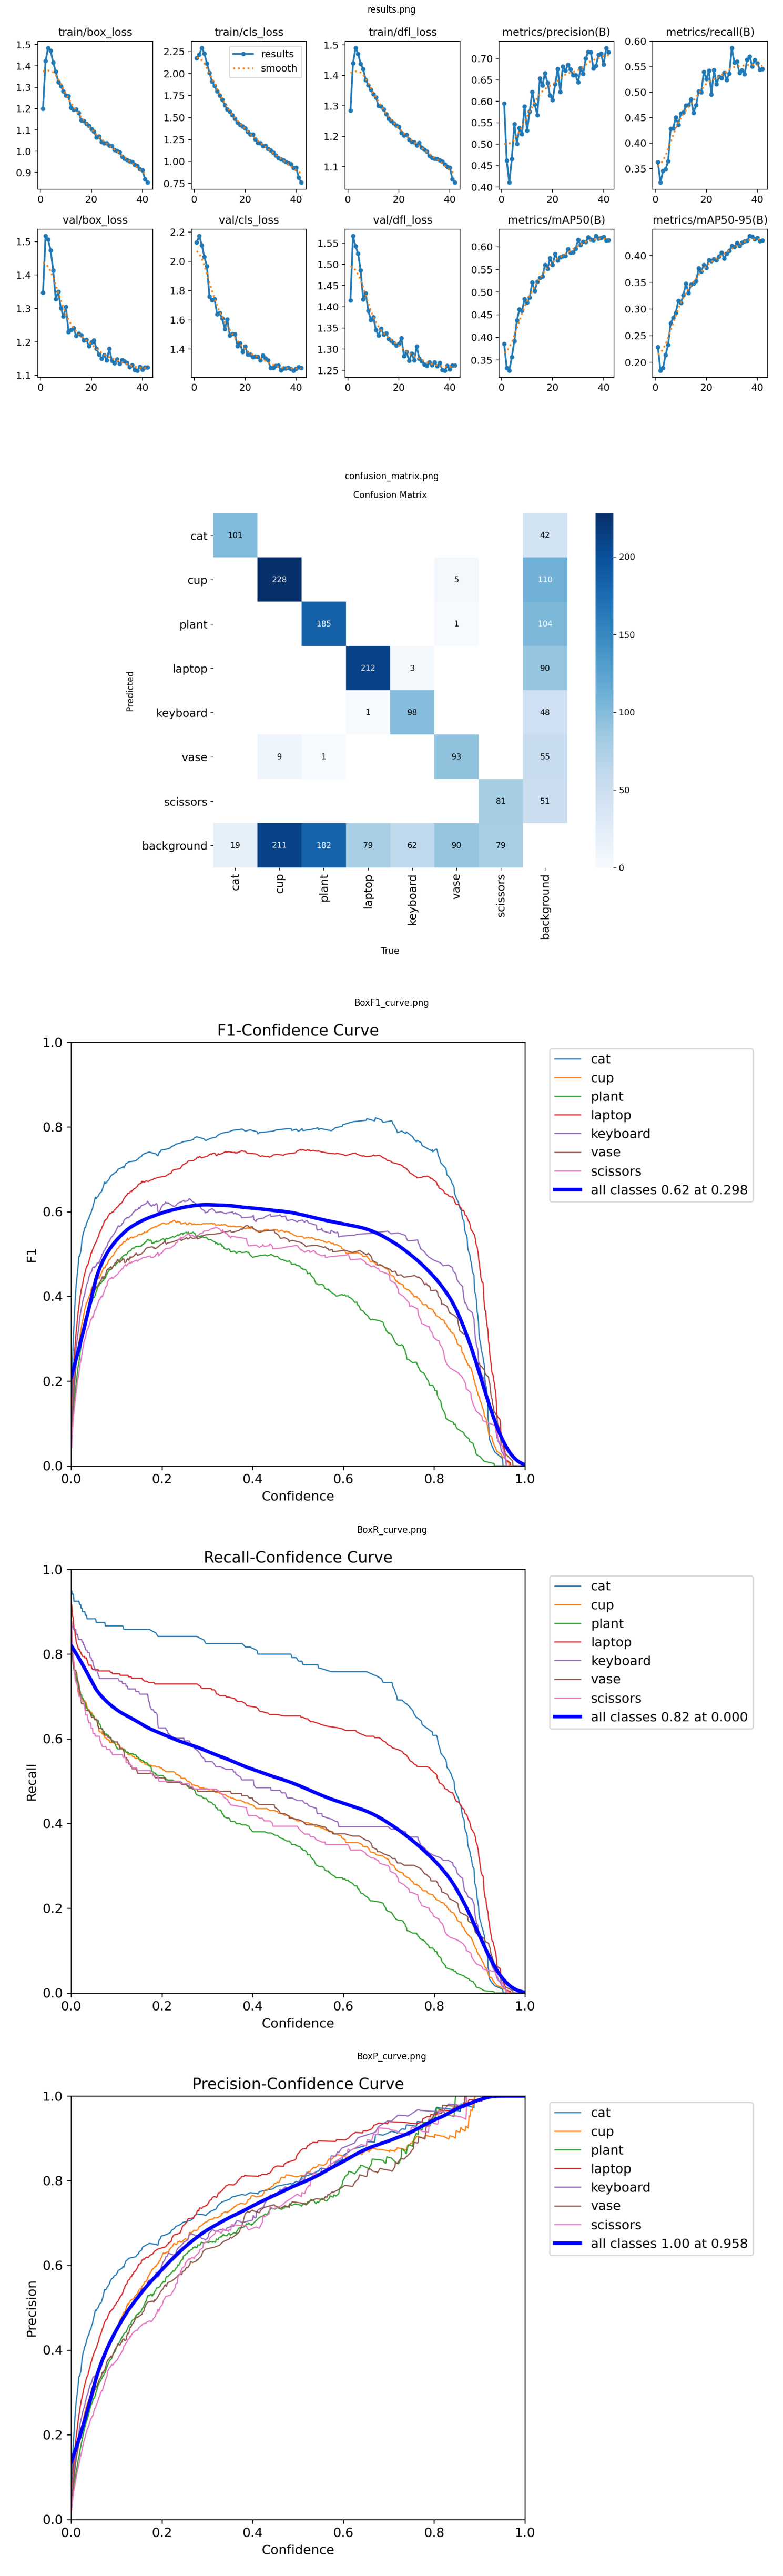

In [3]:
display_image_subplots(
    image_filenames=GRAPH_FILENAMES,
    image_dir="runs/detect/train6",
    num_images=5,
    num_cols=1,
)

clean_up(model)


### Train 4: Increase epochs to 70, image size to 704

In [4]:
DATASET_DIR = "curated_yolo_with_negatives_balanced"

# 1) load pretrained YOLOv8 model
model = YOLO("yolov8s.pt")

# 2) train using your dataset yaml
model.train(
    data=DATASET_DIR+"/data.yaml",
    epochs=70,
    imgsz=704,
    batch=8,
    seed=42,
    device=0,  # use "cpu" if no GPU
    workers=0,  # Fix for Windows multiprocessing issues
    patience=20
)

New https://pypi.org/project/ultralytics/8.4.41 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.32  Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=curated_yolo_with_negatives_balanced/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=70, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=704, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, m

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002A4C19DB1A0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

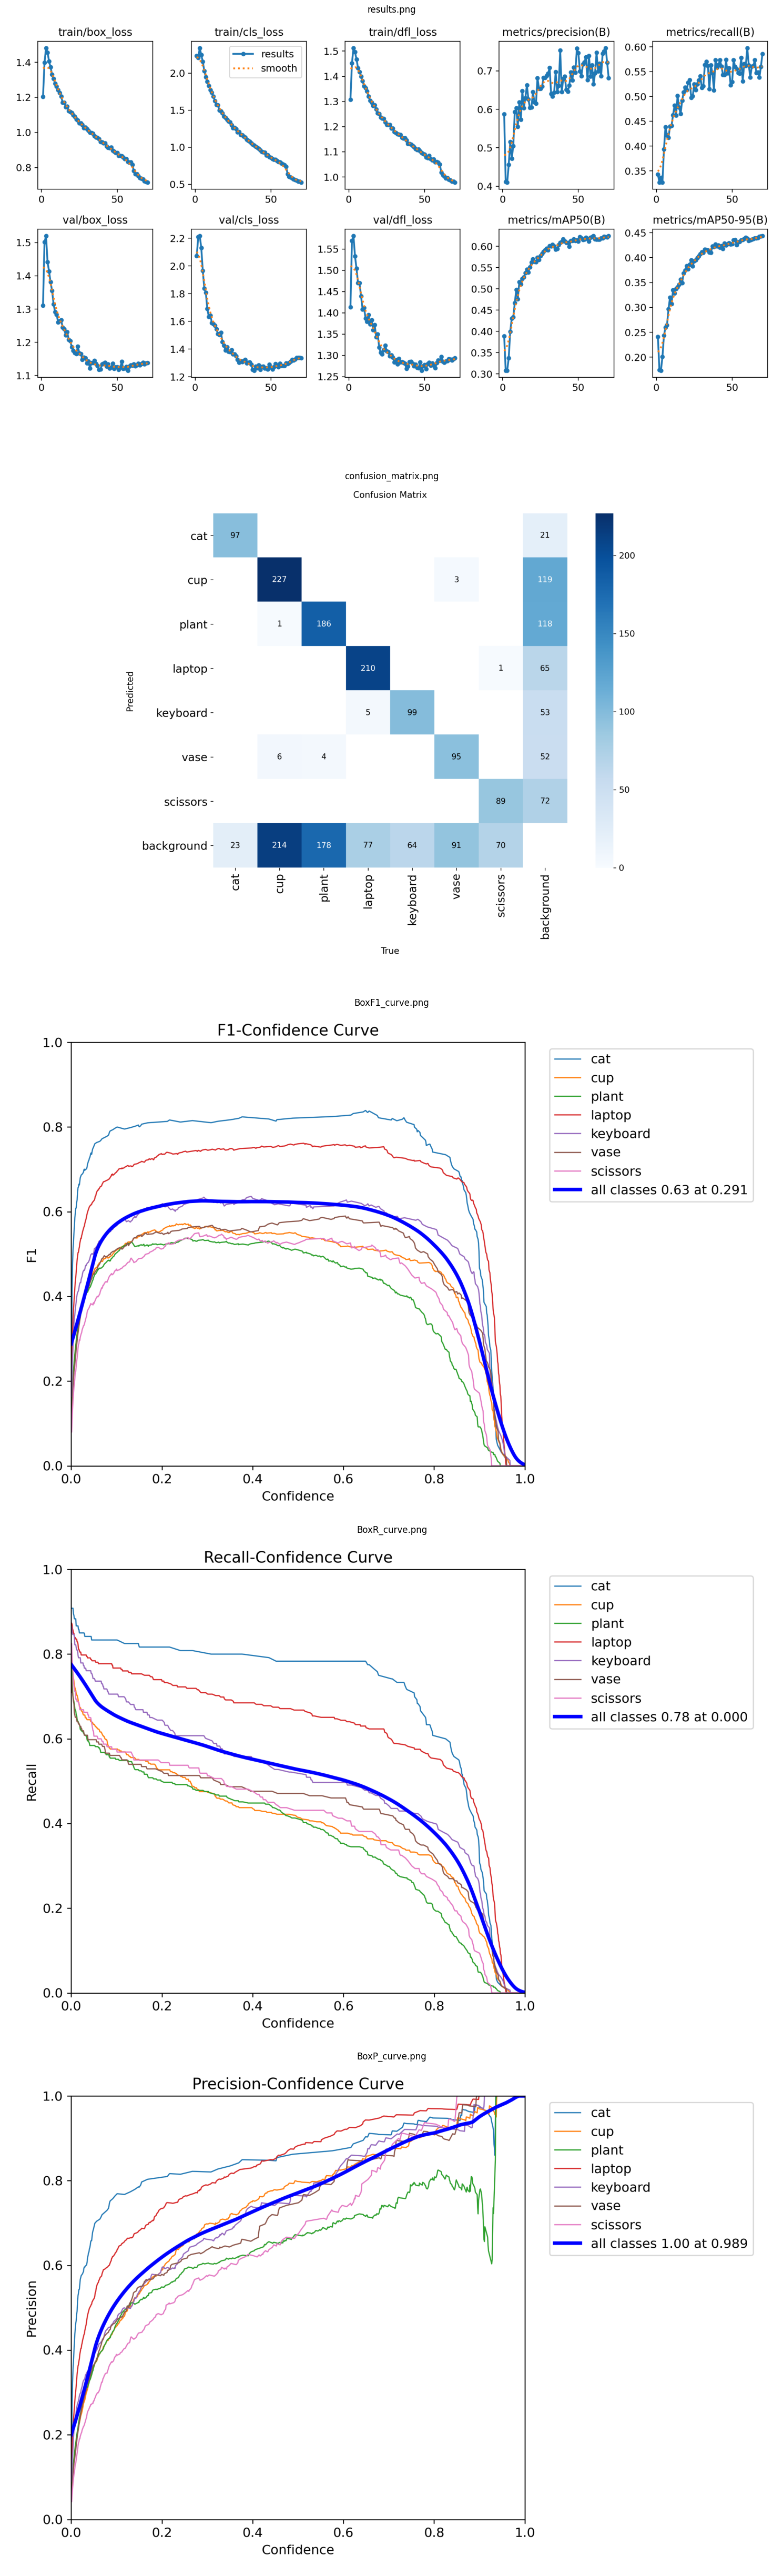

In [5]:
display_image_subplots(
    image_filenames=GRAPH_FILENAMES,
    image_dir="runs/detect/train7",
    num_images=5,
    num_cols=1,
)

### Model validation result of final model

In [8]:
model.val()

Ultralytics 8.4.32  Python-3.12.9 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
val: Fast image access  (ping: 0.10.1 ms, read: 148.177.0 MB/s, size: 156.4 KB)
val: Scanning C:\Users\Sonia Lim\Documents\SMU\EXC_Y3T2\cv\codes\proj\Pet-mischief-detection\curated_yolo_with_negatives_balanced\labels\val.cache... 676 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 676/676  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 43/43 4.9it/s 8.9s0.2s
                   all        676       1740       0.68      0.585      0.624      0.444
                   cat        106        120      0.821      0.803      0.842      0.628
                   cup        224        448       0.69      0.475       0.55      0.405
                 plant        171        368      0.601      0.476      0.457      0.259
                laptop        200        292       0.79      0.709      0.781      0.618
              keybo

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000002A41FA466F0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047

### Predict with final model

In [ ]:
from pathlib import Path

project_dir = Path("runs/detect").resolve()
test_source = Path("curated_yolo_with_negatives_balanced/images/test").resolve()
weights_path = Path("runs/detect/train7/weights/best.pt").resolve()

if not weights_path.is_file():
    raise FileNotFoundError(f"Missing trained weights at {weights_path}")
if not test_source.is_dir():
    raise FileNotFoundError(f"Missing test images directory at {test_source}")

model = YOLO(str(weights_path))
results = model.predict(
    source=str(test_source),
    conf=0.25,
    imgsz=640,
    save=True,
    project=str(project_dir),
    name="predict_train7_test",
    exist_ok=True,
    verbose=False,
)

print(f"Saved predictions to {results[0].save_dir if results else project_dir / 'predict_train7_test'}")